# 🧪LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points)

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS). 


b. Why might PCR fail to find directions that are useful for predicting the response `Y`? 
 

c. In PLS, how is the first direction `Z₁` computed? 


d. What are some similarities and differences between PLS and penalized regression? 


A. The key difference is that PCR identifies directions that explain the most variance among the predictors in an unsupervised way, meaning the response is not used to construct the components. In contrast, PLS is a supervised approach that uses the response to identify directions that maximize the covariance between the predictors and the target.

B. Because PCR doesn't use the response to find the directions that are useful for predicting the response its considered unsupervised and that could mean that it doesn't pick the good directions.

C. $Z_1 = \sum_{j=1}^p \phi_{j1} X_j$is computed by setting each coefficient $\phi_{j1}$ equal to the slope from a simple linear regression of $Y$ onto $X_j$.

D. Both PLS and penalized regression introduce bias to shrink variance and effectively resolve multicollinearity and high dimensionality ($p > n$). However, while PLS achieves this via dimension reduction, penalized regression retains the original predictor space and shrinks the regression coefficients directly using penalty terms like L2 or L1 norms. 

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

📘 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component. 

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## fit a PLSRegression model with 1 component

rng = np.random.RandomState(0)
n_samples = 500

cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)

pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rng)
print(X_train.shape, X_test.shape)

pls = PLSRegression(n_components=1).fit(X_train, y_train)
y_pred = pls.predict(X_test)

#R2 score and RMSE
r2_score = pls.score(X_test, y_test)
rmse = np.sqrt(np.mean((y_test - y_pred.ravel()) ** 2))
print(f"R2 score: {r2_score:.4f}")
print(f"RMSE: {rmse:.4f}")  


(400, 2) (100, 2)
R2 score: 0.6842
RMSE: 0.4709


### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

YOUR TEXT HERE

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

In [19]:
pls2 = PLSRegression(n_components=2).fit(X_train, y_train)
y_pred2 = pls2.predict(X_test)

#R2 score and MSE
r2 = pls2.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred2)
print(f"R-squared: {r2:.3f}")
print(f"MSE: {mse:.3f}")         



R-squared: 0.684
MSE: 0.222


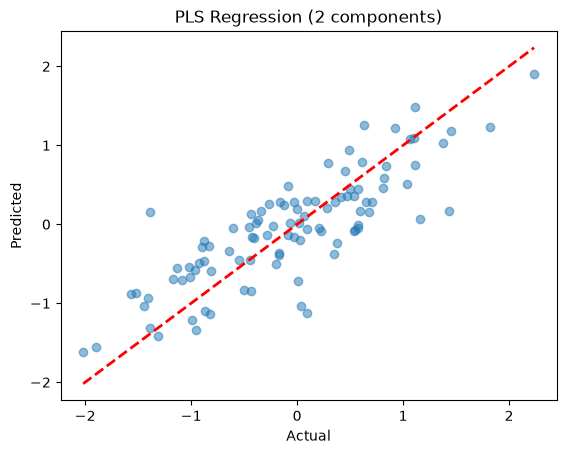

In [20]:
#plot the predicted vs actual values for new model on the test set
plt.scatter(y_test, y_pred2, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('PLS Regression (2 components)')
plt.show()


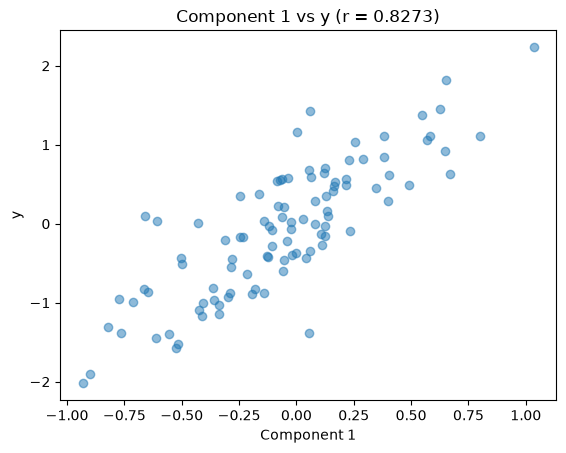

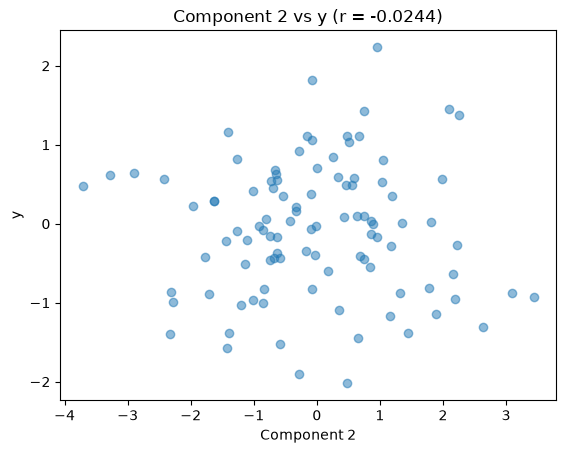

In [21]:
# On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.
components = pls2.transform(X_test)
for i in range(components.shape[1]):
    plt.figure()
    plt.scatter(components[:, i], y_test, alpha=0.5)
    plt.xlabel(f'Component {i + 1}')
    plt.ylabel('y')
    corr = np.corrcoef(components[:, i], y_test)[0, 1]
    plt.title(f'Component {i + 1} vs y (r = {corr:.4f})')
    plt.show()

### d. Reflect
Finally, answer these questions:

- What do the learned PLS components represent in your dataset?
- Did increasing the number of components improve performance?
- What makes PLS different from PCA?

What do the learned PLS components represent in your dataset? 

Each PLS component is a linear combination of the two predictors, with weights chosen to maximize shared covariance with the response variable $y$. Because $y$ was generated from the second principal component direction of $X$, the first PLS component captures this target signal almost immediately—achieving a strong correlation of about $0.827$ with $y$, while the second component accounts for very little predictive signal (a correlation of just $-0.02$).

Did increasing the number of components improve performance? 

No increasing the number of components did not increase the performance because almost all the variance was already captured in the first component. 

What makes PLS different from PCA? 

PCA is an unsupervised technique that creates components solely to maximize the variance within the predictor matrix $X$, completely ignoring the response variable $y$. In contrast, PLS is a supervised technique that constructs components to maximize the covariance between $X$ and $y$, directly prioritizing directions that are predictive of the outcome.



## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).

### b. Create a pipeline.

Create a pipeline that includes the following: 

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.

### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.


### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²

### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.


### f. Reflect

Discuss:
- Which model performed best?
- Would you trust any of your models enough to replace the permeability lab assay?
- What would be the trade-offs of doing so?

In [23]:
# a. Prepare Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error


url = "https://raw.githubusercontent.com/UVADS/DS-4021/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv"
df = pd.read_csv(url)


X = df.drop(columns=["permeability"]).values
y = df["permeability"].values
print("Full dataset shape:", df.shape)
print("X shape:", X.shape, "| y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("Training set shape:", X_train.shape, "| Test set shape:", X_test.shape)

# b. create pipeline 
pls_pipe = Pipeline([
    ("vt", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("pls", PLSRegression()),
])

# c. Optimize the pipeline with GridSearchCV
# create parameter grid for GridSearchCV
param_grid = {
    "pls__n_components": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
}      

cv = KFold(n_splits=5, shuffle=True, random_state=42)
pls_grid = GridSearchCV(pls_pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1)
pls_grid.fit(X_train, y_train)

print("Number of predictors after VarianceThreshold:", pls_grid.best_estimator_.named_steps["vt"].transform(X_train).shape[1])
print("Selected number of components:", pls_grid.best_params_["pls__n_components"])
print("Best R2 score on training set:", pls_grid.best_score_)


# d. Evaluate the model on the test set
best_pls_model = pls_grid.best_estimator_
y_pred_test = best_pls_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)
print("R2 score on reporting set:", test_r2)    

Full dataset shape: (165, 1108)
X shape: (165, 1107) | y shape: (165,)
Training set shape: (115, 1107) | Test set shape: (50, 1107)
Number of predictors after VarianceThreshold: 632
Selected number of components: 3
Best R2 score on training set: 0.3302478466650904
R2 score on reporting set: 0.40812588142077244


In [ ]:
# YOUR ANSWERS FROM HERE (USE AS MANY CELLS AS NEEDED)

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

Our group didn't encounter a huge problem but moving forward, it might be helpful to divide the notebooks by section so we aren't all working through the entire analysis individually. Splitting up tasks would help reduce overlap and give everyone a bit more breathing room instead of rushing near the finish line. We could then come together to review each other’s parts, which would make the workflow feel much smoother and more manageable.